# 01 - Exploratory Data Analysis

This notebook profiles the MIND-small training split before modeling. It focuses on audience behavior, news taxonomy, impression structure, and time patterns that matter for recommendation quality.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
SRC_DIR = PROJECT_ROOT / 'src'
sys.path.append(str(SRC_DIR))

from data_loader import load_behaviors, load_news, parse_history, parse_impressions

sns.set_theme(style='whitegrid', palette='viridis')
DATA_DIR = PROJECT_ROOT / 'data' / 'MINDsmall_train'
news = load_news(DATA_DIR / 'news.tsv')
behaviors = load_behaviors(DATA_DIR / 'behaviors.tsv')
news.head()

,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."
3,N53526,health,voices,I Was An NBA Wife. Here's How It Affected My M...,"I felt like I was a fraud, and being an NBA wi...",https://assets.msn.com/labs/mind/AACk2N6.html,[],"[{""Label"": ""National Basketball Association"", ..."
4,N38324,health,medical,"How to Get Rid of Skin Tags, According to a De...","They seem harmless, but there's a very good re...",https://assets.msn.com/labs/mind/AAAKEkt.html,"[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI...","[{""Label"": ""Skin tag"", ""Type"": ""C"", ""WikidataI..."


## Basic Dataset Statistics

These counts give a quick sense of the scale of the candidate pool, active users, and recommendation events available for training.

In [2]:
stats = {
    'unique_users': behaviors['user_id'].nunique(),
    'unique_articles': news['news_id'].nunique(),
    'impressions': len(behaviors),
    'categories': news['category'].nunique(),
    'subcategories': news['subcategory'].nunique(),
}
pd.Series(stats).to_frame('count')

,count
unique_users,50000
unique_articles,51282
impressions,156965
categories,17
subcategories,264


This table establishes the recommendation scale: 50,000 users, 51,282 articles, and 156,965 impression events. The large gap between 17 broad categories and 264 subcategories means the model must learn both coarse interests, such as news or sports, and finer topic preferences.

## 1. Category Distribution

Recommendation models can overfit to dominant categories. This chart shows whether the article catalog is balanced across top-level news categories.

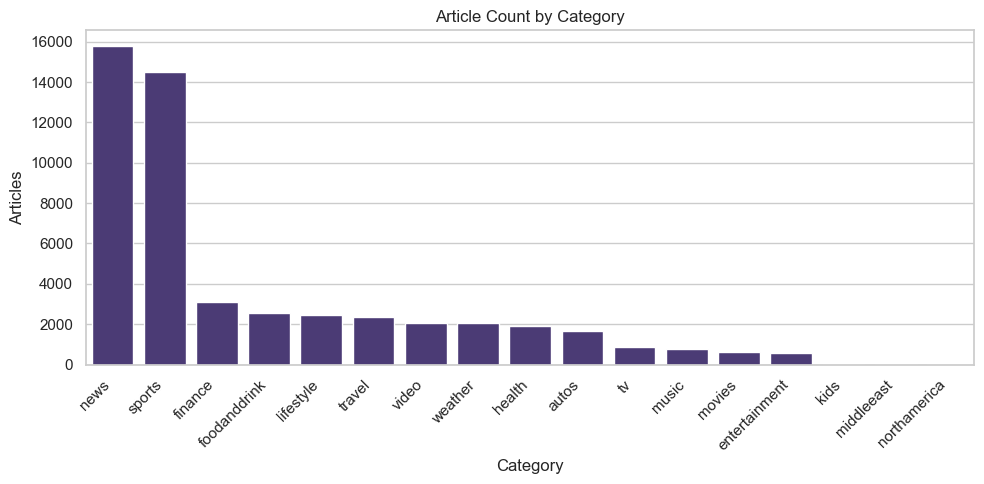

In [3]:
plt.figure(figsize=(10, 5))
category_counts = news['category'].value_counts()
sns.barplot(x=category_counts.index, y=category_counts.values)
plt.title('Article Count by Category')
plt.xlabel('Category')
plt.ylabel('Articles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The category distribution shows which content areas dominate the article catalog (news and sports). If a few categories are much larger than the rest, the recommender can become biased toward those categories unless evaluation and sampling are checked carefully.

## 2. Top Subcategories

Subcategories are more granular than categories and often reveal content clusters such as politics, football, finance, or lifestyle topics.

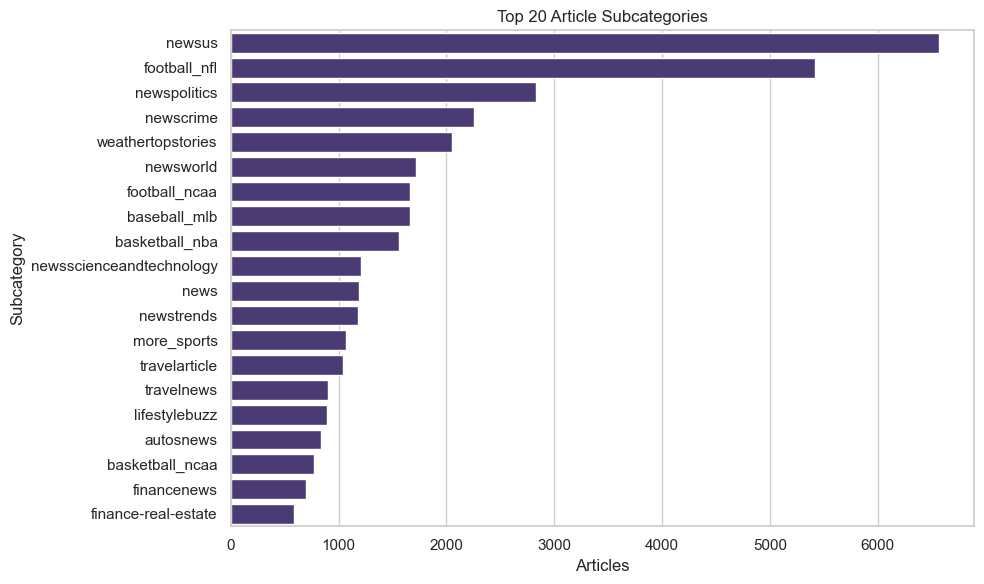

In [4]:
plt.figure(figsize=(10, 6))
subcat_counts = news['subcategory'].value_counts().head(20)
sns.barplot(x=subcat_counts.values, y=subcat_counts.index)
plt.title('Top 20 Article Subcategories')
plt.xlabel('Articles')
plt.ylabel('Subcategory')
plt.tight_layout()
plt.show()

The top subcategories reveal the most common niche topics in the catalog (newsus and football_nfl). These are useful for diagnosing whether strong model performance comes from broad personalization or simply from repeatedly recommending popular topic clusters.

## Behavior-Derived Features

The next cells parse clicked histories and impressions into numeric features for user and ranking analysis.

In [5]:
eda = behaviors.copy()
eda['history_length'] = eda['history'].apply(lambda value: len(parse_history(value)))
eda['parsed_impressions'] = eda['impressions'].apply(parse_impressions)
eda['impression_size'] = eda['parsed_impressions'].apply(len)
eda['clicked_in_impression'] = eda['parsed_impressions'].apply(lambda items: sum(label for _, label in items))
eda['time'] = pd.to_datetime(eda['time'])
eda['hour'] = eda['time'].dt.hour
eda[['history_length', 'impression_size', 'clicked_in_impression', 'hour']].describe()

,history_length,impression_size,clicked_in_impression,hour
count,156965.000000,156965.000000,156965.000000,156965.000000
mean,32.539987,37.227688,1.505711,10.849654
std,40.267607,38.594148,1.153102,4.875294
min,0.000000,2.000000,1.000000,0.000000
25%,8.000000,10.000000,1.000000,7.000000
50%,19.000000,24.000000,1.000000,11.000000
75%,42.000000,51.000000,2.000000,14.000000
max,558.000000,299.000000,35.000000,23.000000


These summary statistics describe the behavioral signals used by NRMS. `history_length` measures how much user context is available, `impression_size` controls ranking difficulty, and `clicked_in_impression` tells us how many positives may appear in one recommendation event.

## 3. User Click Distribution

This visual shows how many historical clicked articles are available per user-impression row. Heavy skew means many users have sparse behavioral context.

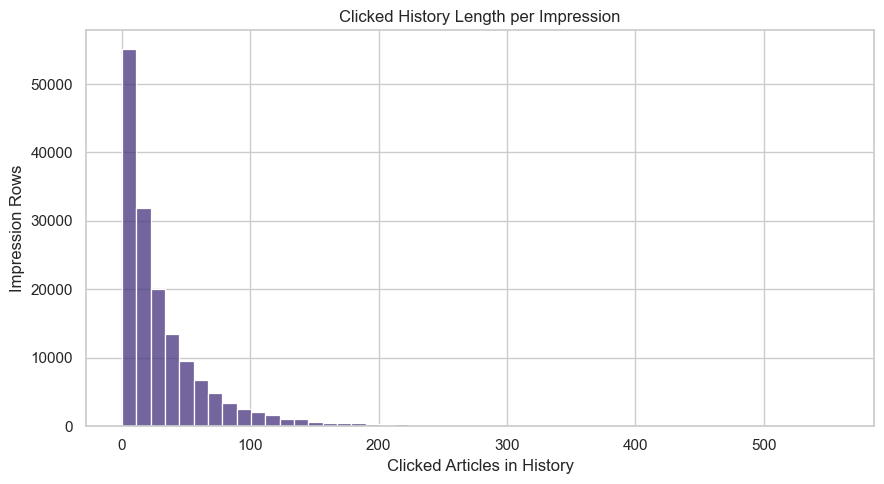

In [6]:
plt.figure(figsize=(9, 5))
sns.histplot(eda['history_length'], bins=50, kde=False)
plt.title('Clicked History Length per Impression')
plt.xlabel('Clicked Articles in History')
plt.ylabel('Impression Rows')
plt.tight_layout()
plt.show()

This plot helps identify sparse-history users. Rows near zero are harder for a history-based model because the user encoder has little evidence, while long histories provide richer personalization signals.

## 4. History Length by User

Aggregating by user highlights whether engagement is concentrated among a small number of highly active readers.

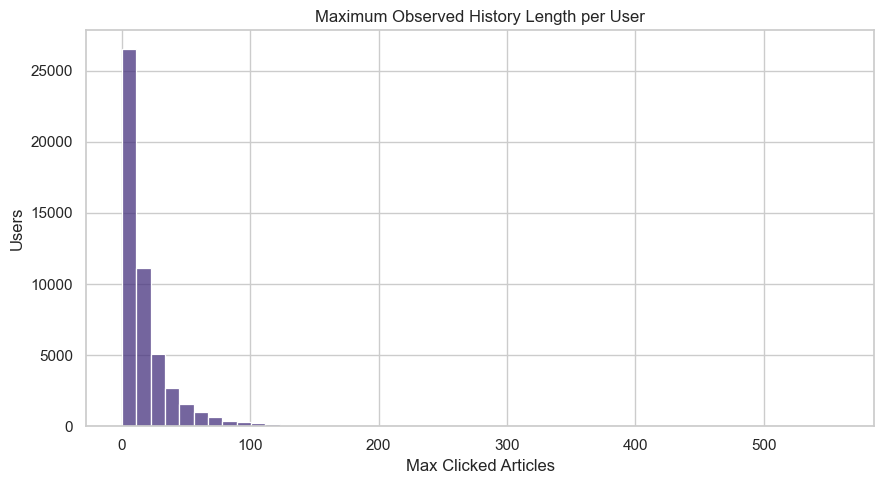

In [7]:
user_history = eda.groupby('user_id')['history_length'].max()
plt.figure(figsize=(9, 5))
sns.histplot(user_history, bins=50)
plt.title('Maximum Observed History Length per User')
plt.xlabel('Max Clicked Articles')
plt.ylabel('Users')
plt.tight_layout()
plt.show()

This user-level view shows whether engagement is concentrated among a subset of highly active readers. A long right tail usually means the model will learn stronger profiles for frequent users than for casual or new users.

## 5. Impression Size Analysis

MIND impressions contain variable numbers of candidate articles. Ranking metrics such as MRR and nDCG are computed within these impression groups.

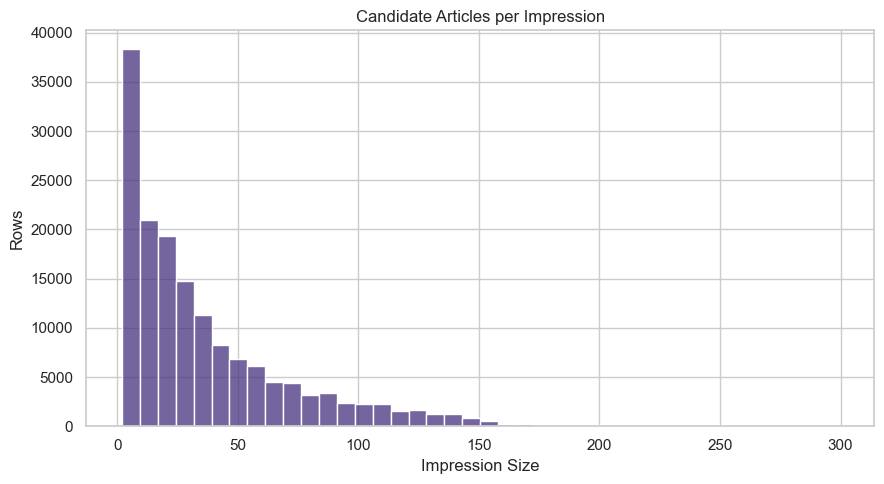

In [8]:
plt.figure(figsize=(9, 5))
sns.histplot(eda['impression_size'], bins=40)
plt.title('Candidate Articles per Impression')
plt.xlabel('Impression Size')
plt.ylabel('Rows')
plt.tight_layout()
plt.show()

Impression size is the number of candidates the model must rank for a user. Larger impressions are harder because the clicked article must be placed above more non-clicked articles, which directly affects MRR and nDCG.

## 6. Clicks per Impression

Most impressions contain one clicked item, but checking this distribution is useful because evaluation code should handle multiple positives correctly.

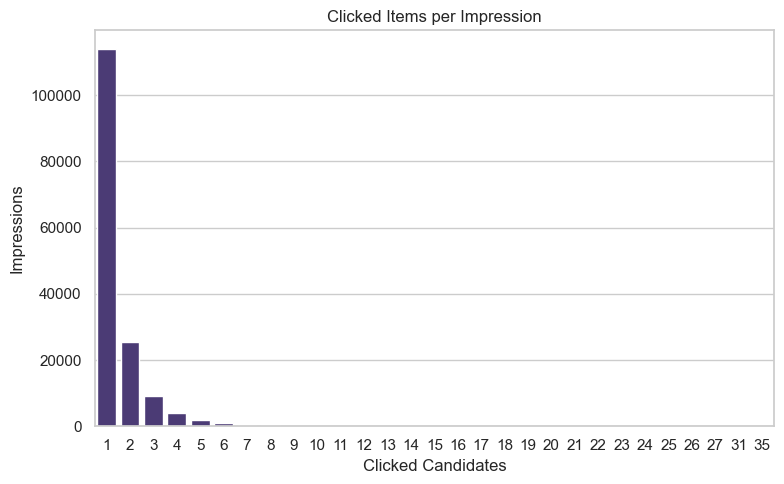

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(x=eda['clicked_in_impression'])
plt.title('Clicked Items per Impression')
plt.xlabel('Clicked Candidates')
plt.ylabel('Impressions')
plt.tight_layout()
plt.show()

This chart shows how many clicked candidates appear per impression. The evaluation code supports multiple positives, but impressions with one clicked item are the most straightforward ranking cases.

## 7. Temporal Patterns

Traffic by hour can expose daily usage cycles. These patterns often matter when freshness and recency features are added to a recommender.

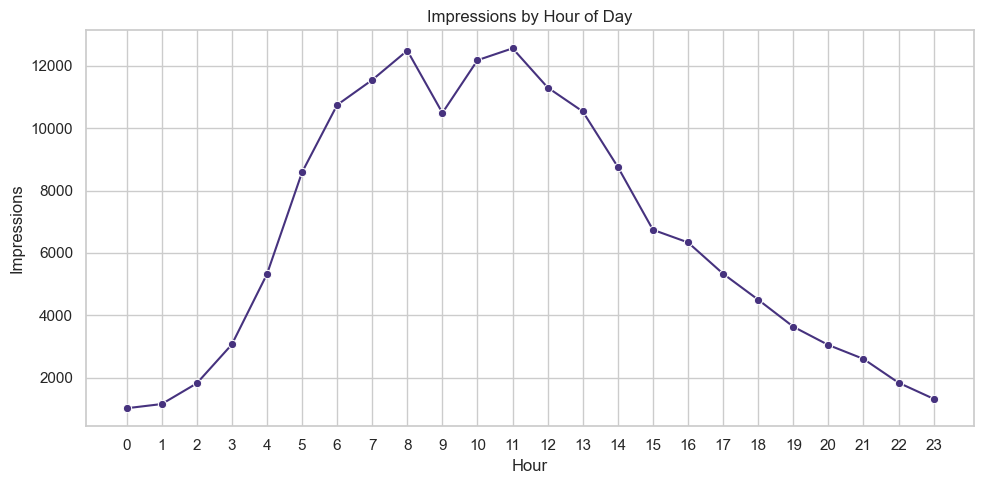

In [10]:
hourly = eda.groupby('hour').size().reindex(range(24), fill_value=0)
plt.figure(figsize=(10, 5))
sns.lineplot(x=hourly.index, y=hourly.values, marker='o')
plt.title('Impressions by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Impressions')
plt.xticks(range(24))
plt.tight_layout()
plt.show()

The hourly pattern indicates when users are most active. NRMS does not currently use time as a feature, so strong temporal cycles point to a possible improvement: adding freshness, recency, or time-aware ranking features.